In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import numpy_financial as npf
from scipy.stats import triang


#  Thông số dự án

PROJECT_LIFE = 20
MARR = 0.09

OM_GROWTH = 0.03

N_SIM = 10000
# Khóa bộ số ngẫu nhiên để kết quả tái lập

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)


#  Phân phối xác suất các biến đầu vào

# Sản lượng điện hàng năm (kWh)

GEN_P50 = 1400000

GEN_P90 = 1260000

GEN_MEAN = GEN_P50

GEN_STD = (
    GEN_P50 - GEN_P90
) / 1.282

# Chi phí đầu tư ban đầu (VND)

CAPEX_MIN = 14e9
CAPEX_MODE = 15e9
CAPEX_MAX = 16e9

# Giá bán điện (VND/kWh)

PRICE_MIN = 1150
PRICE_MODE = 2204
PRICE_MAX = 3600

# Giá trị cơ sở

GEN_BASE = GEN_MEAN

CAPEX_BASE = (
    CAPEX_MIN
    + CAPEX_MODE
    + CAPEX_MAX
) / 3

PRICE_BASE = (
    PRICE_MIN
    + PRICE_MODE
    + PRICE_MAX
) / 3


#  Hàm tính NPV

def calculate_npv(
        generation,
        price,
        capex):

    annual_revenue = (
        generation * price
    )

    # Giá trị hiện tại của doanh thu

    annuity_factor = (
        ((1 + MARR) ** PROJECT_LIFE - 1)
        /
        (MARR * (1 + MARR) ** PROJECT_LIFE)
    )

    pv_revenue = (
        annual_revenue
        * annuity_factor
    )

    # Giá trị hiện tại của chi phí vận hành và bảo trì

    om1 = 75_000_000

    pv_om = 0

    for t in range(1, PROJECT_LIFE + 1):

        om_t = (
            om1
            * (1 + OM_GROWTH) ** (t - 1)
        )

        pv_om += (
            om_t
            /
            (1 + MARR) ** t
        )

    npv = (
        pv_revenue
        - pv_om
        - capex
    )

    return npv

#  Hàm tính IRR

def calculate_irr(
        generation,
        price,
        capex):

    annual_revenue = (
        generation * price
    )

    om1 = (
        75_000_000
    )

    cashflows = [-capex]

    for t in range(1, PROJECT_LIFE + 1):

        om_t = (
            om1
            * (1 + OM_GROWTH) ** (t - 1)
        )

        cf_t = (
            annual_revenue
            - om_t
        )

        cashflows.append(cf_t)

    return npf.irr(cashflows)

#  Đánh giá hiệu quả dự án

def evaluate_project(
        generation,
        price,
        capex):

    npv = calculate_npv(
        generation,
        price,
        capex
    )

    irr = calculate_irr(
        generation,
        price,
        capex
    )

    return npv, irr

#  Tính toán kịch bản cơ sở

base_npv, base_irr = evaluate_project(
    GEN_BASE,
    PRICE_BASE,
    CAPEX_BASE
)

print("BASE CASE")

print(
    f"NPV = {base_npv:,.0f} VND"
)

print(
    f"IRR = {base_irr*100:.2f}%"
)

#  Hàm mô phỏng MONTE CARLO 

def monte_carlo(
        vary_generation=False,
        vary_capex=False,
        vary_price=False):

    npvs = []
    irrs = []

    for _ in range(N_SIM):

        generation = GEN_BASE
        capex = CAPEX_BASE
        price = PRICE_BASE

        # Sản lượng điện

        if vary_generation:

         generation = np.random.normal(
            GEN_MEAN,
            GEN_STD
    )

        # Chi phí đầu tư ban đầu

        if vary_capex:

            c_capex = (
                CAPEX_MODE
                - CAPEX_MIN
            ) / (
                CAPEX_MAX
                - CAPEX_MIN
            )

            capex = triang.rvs(
                c_capex,
                loc=CAPEX_MIN,
                scale=CAPEX_MAX-CAPEX_MIN
            )

        # Giá bán điện

        if vary_price:

            c_price = (
                PRICE_MODE
                - PRICE_MIN
            ) / (
                PRICE_MAX
                - PRICE_MIN
            )

            price = triang.rvs(
                c_price,
                loc=PRICE_MIN,
                scale=PRICE_MAX-PRICE_MIN
            )

        npv, irr = evaluate_project(
            generation,
            price,
            capex
        )

        npvs.append(npv)
        irrs.append(irr)

    return (
        np.array(npvs),
        np.array(irrs)
    )

#  Kịch bản 1
# Chỉ sản lượng điện biến động
NPV_GEN, IRR_GEN = monte_carlo(
    vary_generation=True
)


#  Kịch bản 2
# Chỉ chi phí đầu tư ban đầu biến động


NPV_CAPEX, IRR_CAPEX = monte_carlo(
    vary_capex=True
)
#  Kịch bản 3
# Chỉ giá bán điện biến động

NPV_PRICE, IRR_PRICE = monte_carlo(
    vary_price=True
)

# Kịch bản 4
# Tất cả 3 biến cùng biến động

NPV_ALL, IRR_ALL = monte_carlo(
    vary_generation=True,
    vary_capex=True,
    vary_price=True
)

# Tổng hợp kết quả
def summarize(
        name,
        npvs,
        ):

    return {

        "Scenario":
        name,

        "Mean NPV":
        np.mean(npvs),

        "Std NPV":
        np.std(npvs),

        "CV":
        np.std(npvs)
        /
        abs(np.mean(npvs)),

        "P(NPV<0)%":
        np.mean(npvs < 0)
        * 100,

        
    }

results = pd.DataFrame([
    summarize("Generation", NPV_GEN),
    summarize("CAPEX", NPV_CAPEX),
    summarize("Price", NPV_PRICE),
    summarize("All Variables", NPV_ALL),
])

print("MONTE CARLO NPV RESULTS")

print(results)


BASE CASE
NPV = 13,776,788,949 VND
IRR = 20.56%
MONTE CARLO NPV RESULTS
        Scenario      Mean NPV       Std NPV        CV  P(NPV<0)%
0     Generation  1.377185e+10  2.318646e+09  0.168361       0.00
1          CAPEX  1.376692e+10  4.106833e+08  0.029831       0.00
2          Price  1.370724e+10  6.358325e+09  0.463866       0.23
3  All Variables  1.374169e+10  6.827689e+09  0.496860       0.87


In [30]:
#Kiểm tra xác xuất sản lượng điện có giá trị nhỏ hơn hoặc bằng 0 trong phân phối chuẩn
from scipy.stats import norm

mu = 1400000
sigma = (1400000 - 1260000)/1.282

prob_negative = norm.cdf(0, loc=mu, scale=sigma)

print("xác xuất sản lượng điện có giá trị nhỏ hơn hoặc bằng 0:", prob_negative)

xác xuất sản lượng điện có giá trị nhỏ hơn hoặc bằng 0: 6.335026210803338e-38


In [31]:

# TỔNG HỢP KẾT QUẢ IRR
def summarize_irr(
        name,
        irrs):

    return {

        "Scenario":
        name,

        "Mean IRR (%)":
        np.mean(irrs)
        * 100,

        "Std IRR (%)":
        np.std(irrs)
        * 100,

        "CV":
        np.std(irrs)
        /
        abs(np.mean(irrs)),

        "P(IRR<MARR)%":
        np.mean(irrs < MARR)
        * 100
    }

# BẢNG KẾT QUẢ IRR

irr_results = pd.DataFrame([

    summarize_irr(
        "Generation",
        IRR_GEN
    ),

    summarize_irr(
        "CAPEX",
        IRR_CAPEX
    ),

    summarize_irr(
        "Price",
        IRR_PRICE
    ),

    summarize_irr(
        "All Variables",
        IRR_ALL
    )

])

print("IRR RESULTS")

print(irr_results)

IRR RESULTS
        Scenario  Mean IRR (%)  Std IRR (%)        CV  P(IRR<MARR)%
0     Generation     20.543289     1.811551  0.088182          0.00
1          CAPEX     20.560883     0.616586  0.029988          0.00
2          Price     20.401659     5.001546  0.245154          0.23
3  All Variables     20.428332     5.400378  0.264357          0.87


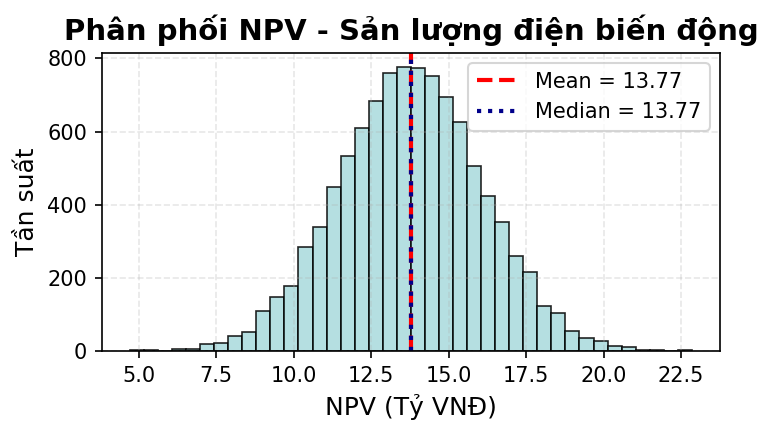

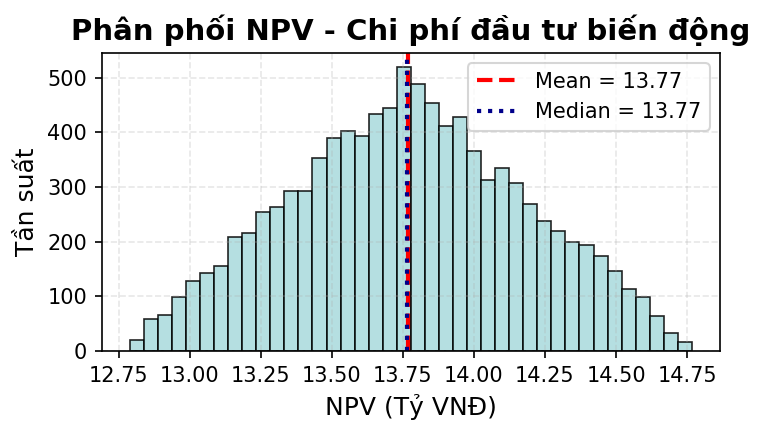

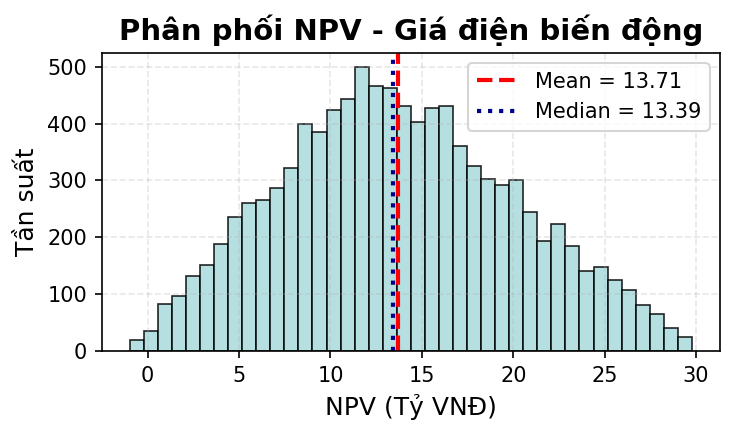

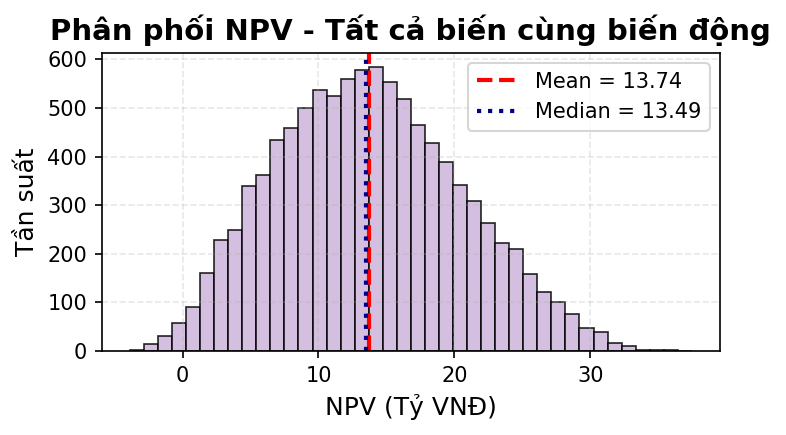

In [32]:

# BIỂU ĐỒ PHÂN PHỐI NPV

def plot_histogram(data, title, color):

    plt.figure(
        figsize=(5, 3),
        dpi=150
    )

    plt.hist(
        data/1e9,
        bins=40,
        color=color,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )

    mean_value = np.mean(data)/1e9
    median_value = np.median(data)/1e9

    plt.axvline(
        mean_value,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Mean = {mean_value:.2f}'
    )

    plt.axvline(
        median_value,
        color='darkblue',
        linestyle=':',
        linewidth=2,
        label=f'Median = {median_value:.2f}'
    )

    plt.xlabel(
        "NPV (Tỷ VNĐ)",
        fontsize=12
    )

    plt.ylabel(
        "Tần suất",
        fontsize=12
    )

    plt.title(
        title,
        fontsize=14,
        fontweight='bold'
    )

    plt.grid(
        True,
        linestyle='--',
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# Kịch bản 1
plot_histogram(
    NPV_GEN,
    "Phân phối NPV - Sản lượng điện biến động",
    "#A8DADC"    
)

# Kịch bản 2
plot_histogram(
    NPV_CAPEX,
    "Phân phối NPV - Chi phí đầu tư biến động",
     "#A8DADC"     
)


# Kịch bản 3

plot_histogram(
    NPV_PRICE,
    "Phân phối NPV - Giá điện biến động",
    "#A8DADC" 
)

# Kịch bản 4

plot_histogram(
    NPV_ALL,
    "Phân phối NPV - Tất cả biến cùng biến động",
    "#CDB4DB" 
)

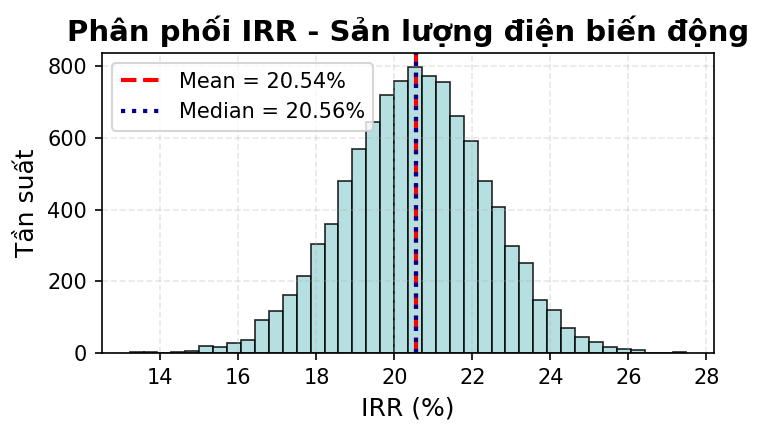

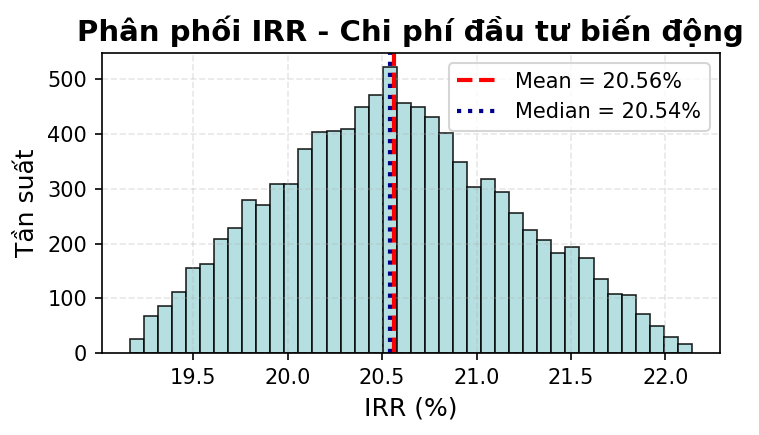

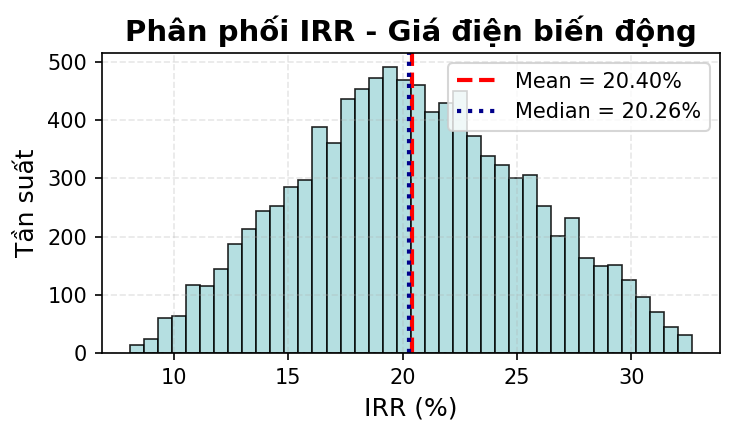

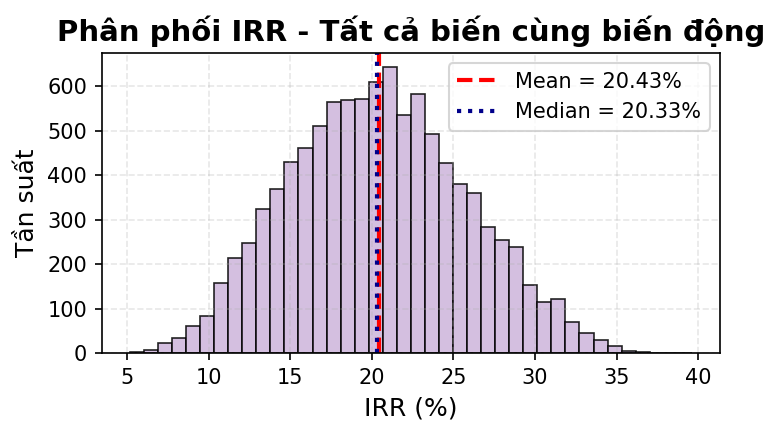

In [33]:
# BIỂU ĐỒ PHÂN PHỐI IRR

def plot_histogram_irr(data, title, color):

    plt.figure(
        figsize=(5, 3),
        dpi=150
    )

    irr_percent = data * 100

    plt.hist(
        irr_percent,
        bins=40,
        color=color,
        edgecolor='black',
        linewidth=0.8,
        alpha=0.85
    )

    mean_value = np.mean(irr_percent)
    median_value = np.median(irr_percent)

    plt.axvline(
        mean_value,
        color='red',
        linestyle='--',
        linewidth=2,
        label=f'Mean = {mean_value:.2f}%'
    )

    plt.axvline(
        median_value,
        color='darkblue',
        linestyle=':',
        linewidth=2,
        label=f'Median = {median_value:.2f}%'
    )

    plt.xlabel(
        "IRR (%)",
        fontsize=12
    )

    plt.ylabel(
        "Tần suất",
        fontsize=12
    )

    plt.title(
        title,
        fontsize=14,
        fontweight='bold'
    )

    plt.grid(
        True,
        linestyle='--',
        alpha=0.3
    )

    plt.legend()

    plt.tight_layout()

    plt.show()


# Kịch bản 1
plot_histogram_irr(
    IRR_GEN,
    "Phân phối IRR - Sản lượng điện biến động",
    "#A8DADC"
)

# Kịch bản 2
plot_histogram_irr(
    IRR_CAPEX,
    "Phân phối IRR - Chi phí đầu tư biến động",
    "#A8DADC"
)

# Kịch bản 3
plot_histogram_irr(
    IRR_PRICE,
    "Phân phối IRR - Giá điện biến động",
    "#A8DADC"
)

# Kịch bản 4
plot_histogram_irr(
    IRR_ALL,
    "Phân phối IRR - Tất cả biến cùng biến động",
    "#CDB4DB"
)


TORNADO TABLE
     Variable           Low          High         Range
2       CAPEX  1.500000e+09 -1.500000e+09 -3.000000e+09
1       Price -2.962396e+09  2.962396e+09  5.924791e+09
0  Generation -2.962396e+09  2.962396e+09  5.924791e+09


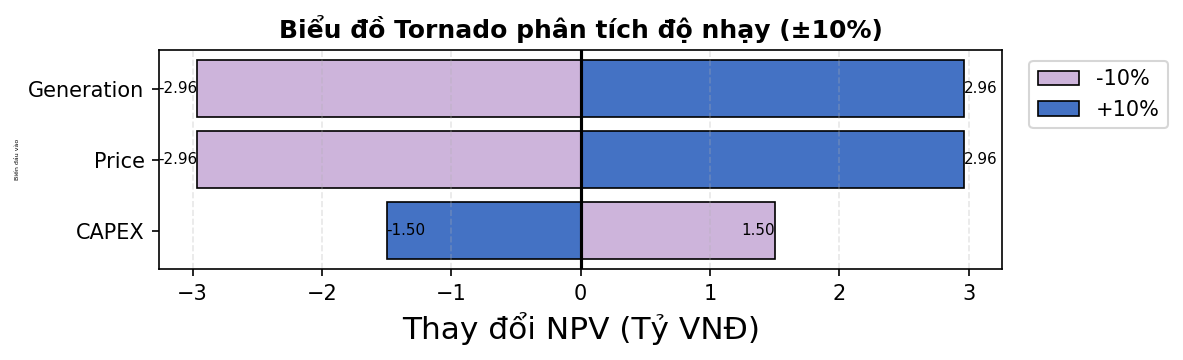

In [37]:
   
# PHÂN TÍCH ĐỘ NHẠY TORNADO (±10%)

base_npv = calculate_npv(
    GEN_BASE,
    PRICE_BASE,
    CAPEX_BASE
)

variables = []

# Generation

npv_low = calculate_npv(
    GEN_BASE * 0.9,
    PRICE_BASE,
    CAPEX_BASE
)

npv_high = calculate_npv(
    GEN_BASE * 1.1,
    PRICE_BASE,
    CAPEX_BASE
)

variables.append([
    "Generation",
    npv_low - base_npv,
    npv_high - base_npv
])

# Price

npv_low = calculate_npv(
    GEN_BASE,
    PRICE_BASE * 0.9,
    CAPEX_BASE
)

npv_high = calculate_npv(
    GEN_BASE,
    PRICE_BASE * 1.1,
    CAPEX_BASE
)

variables.append([
    "Price",
    npv_low - base_npv,
    npv_high - base_npv
])

# CAPEX

npv_low = calculate_npv(
    GEN_BASE,
    PRICE_BASE,
    CAPEX_BASE * 0.9
)

npv_high = calculate_npv(
    GEN_BASE,
    PRICE_BASE,
    CAPEX_BASE * 1.1
)

variables.append([
    "CAPEX",
    npv_low - base_npv,
    npv_high - base_npv
])

# BẢNG DỮ LIỆU TORNADO

tornado = pd.DataFrame(
    variables,
    columns=[
        "Variable",
        "Low",
        "High"
    ]
)

tornado["Range"] = (
    tornado["High"]
    - tornado["Low"]
)

tornado = tornado.sort_values(
    "Range"
)

print("\nTORNADO TABLE")
print(tornado)

#  VẼ BIỂU ĐỒ TORNADO

plt.figure(
    figsize=(8,2.5),
    dpi=150
)

# Thanh giảm NPV
plt.barh(
    tornado["Variable"],
    tornado["Low"]/1e9,
    color="#CDB4DB",      
    edgecolor="black",
    linewidth=0.8,
    label="-10%"
)

# Thanh tăng NPV
plt.barh(
    tornado["Variable"],
    tornado["High"]/1e9,
    color="#4472C4",    
    edgecolor="black",
    linewidth=0.8,
    label="+10%"
)

# Đường NPV cơ sở
plt.axvline(
    0,
    color='black',
    linewidth=1.5
)

plt.xlabel(
    "Thay đổi NPV (Tỷ VNĐ)",
    fontsize=15
)

plt.ylabel(
    "Biến đầu vào",
    fontsize=3
)

plt.title(
    "Biểu đồ Tornado phân tích độ nhạy (±10%)",
    fontsize=12,
    fontweight='bold'
)

plt.grid(
    axis='x',
    linestyle='--',
    alpha=0.3
)

plt.legend(
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)
for i in range(len(tornado)):

    plt.text(
        tornado["Low"].iloc[i]/1e9,
        i,
        f'{tornado["Low"].iloc[i]/1e9:.2f}',
        va='center',
        ha='right',
        fontsize=7.25
    )

    plt.text(
        tornado["High"].iloc[i]/1e9,
        i,
        f'{tornado["High"].iloc[i]/1e9:.2f}',
        va='center',
        ha='left',
        fontsize=7.25
    )
plt.tight_layout()

plt.show()
